### Notebook for plotting NCEP Stage IV and Mesonet Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.interpolate import griddata
from scipy.ndimage import uniform_filter, maximum_filter
from datetime import datetime
import cartopy.io.shapereader as shpreader
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import netCDF4
from netCDF4 import Dataset
import matplotlib as mpl
import wrf
import xarray as xr

### Load Data

In [ ]:
# --- File paths for WRF data for model comparison---
wrf_file_start = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/colin/erin/test/output/raw_original/wrfout_d02_2007-08-18_12:00:00'
wrf_file_end   = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/colin/erin/test/output/raw_original/wrfout_d02_2007-08-19_12:00:00'
stageIV_file   = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/colin60186/ST4.2007081912.24h'

# --- Load WRF data ---
wrf_start = Dataset(wrf_file_start)
wrf_end   = Dataset(wrf_file_end)

lon = wrf_end.variables['XLONG'][0]
lat = wrf_end.variables['XLAT'][0]

precip_end   = wrf_end.variables['RAINC'][0] + wrf_end.variables['RAINNC'][0]
precip_start = wrf_start.variables['RAINC'][0] + wrf_start.variables['RAINNC'][0]
precip_24h = precip_end - precip_start

# Coarsen WRF grid for plotting (optional)
coarsening_factor = 2
coarse_lon = lon[::coarsening_factor, ::coarsening_factor]
coarse_lat = lat[::coarsening_factor, ::coarsening_factor]
coarse_precip = precip_24h[::coarsening_factor, ::coarsening_factor]

# --- Load Stage IV data ---
stageIV = xr.open_dataset(stageIV_file, engine='cfgrib')
rlon = stageIV['longitude'].values
rlat = stageIV['latitude'].values
tp = stageIV['tp'].values



/home/colinwelty/.conda/envs/home/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.30.2
  warnings.warn(


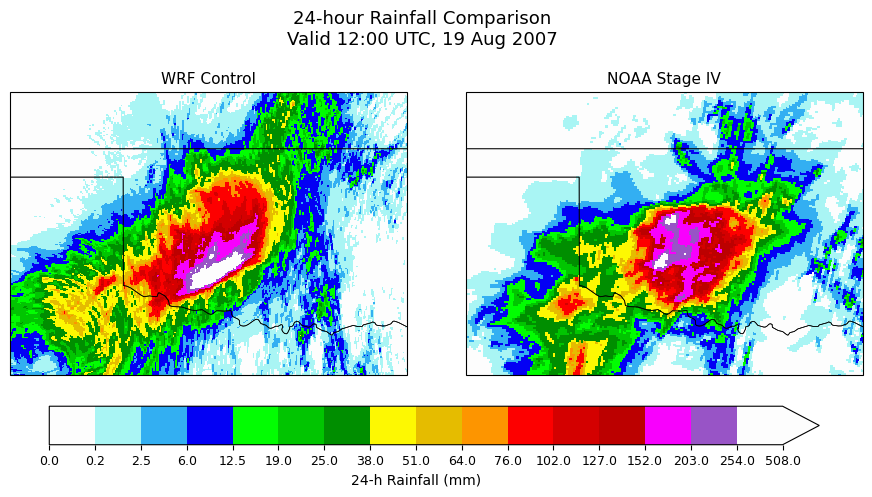

In [ ]:
# --- Colors ---
nws_precip_colors = [
    "#fdfdfd","#a9f5f4","#33aff2","#0300f4","#02fd02","#01c501","#008e00",
    "#fdf802","#e5bc00","#fd9500","#fd0000","#d40000","#bc0000",
    "#f800fd","#9854c6","#fdfdfd"
]
cmap = mpl.colors.ListedColormap(nws_precip_colors)
levels = [0.0, 0.25, 2.5, 6, 12.5, 19, 25, 38, 51, 64, 76, 102, 127,
          152, 203, 254, 508]
norm = mpl.colors.BoundaryNorm(levels, cmap.N)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Adjust spacing between panels
plt.subplots_adjust(wspace=0.15)

# Titles and data list
titles = ['WRF Control', 'NOAA Stage IV']
data_list = [(coarse_lon, coarse_lat, coarse_precip), (rlon, rlat, tp)]

# Expanded extent
extent = [-102, -95, 33, 38]

for ax, (lon_data, lat_data, precip_data), title in zip(axes, data_list, titles):
    pcm = ax.pcolormesh(lon_data, lat_data, precip_data, cmap=cmap, norm=norm)
    ax.set_title(title, fontsize=11, fontweight='normal')
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.4)

# Shared colorbar
cbar = fig.colorbar(pcm, ax=axes, orientation='horizontal', fraction=0.1, pad=0.08,
                    extend='max', ticks=levels)
cbar.set_label("24-h Rainfall (mm)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Supertitle
fig.suptitle("24-hour Rainfall Comparison\nValid 12:00 UTC, 19 Aug 2007",
             fontsize=13, fontweight='normal')

# Save figure
plt.savefig("wrf_stageIV_24h.pdf", dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

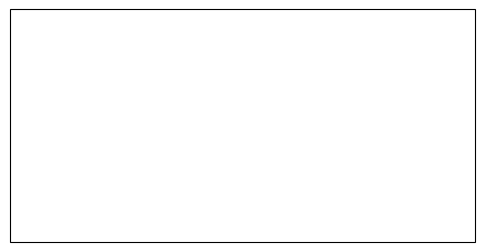

In [ ]:
# --- Load station metadata ---
geo = pd.read_csv(
    "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/2007_Erin_Data/geoinfo.csv",
    usecols=["stid","nlat","elon","name","city","elev"]
)

# --- Helpers ---
def load_station_data(stid, date):
    fpath = f"/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/2007_Erin_Data/{stid}_{date}.csv"
    df = pd.read_csv(fpath, parse_dates=["time"])
    return df

def load_all_stations(stids, dates):
    dfs = []
    for stid in stids:
        for date in dates:
            try:
                df = load_station_data(stid, date)
                dfs.append(df)
            except FileNotFoundError:
                continue
    return pd.concat(dfs, ignore_index=True)

# --- Step 1: Load Mesonet data ---
dates = ["20070818", "20070819"]
all_stids = geo["stid"].unique()
data = load_all_stations(all_stids, dates)

# --- Step 2: Filter 03–09 UTC 19 Aug 2007 ---
t1 = pd.to_datetime("2007-08-18 12:00:00")
t2 = pd.to_datetime("2007-08-19 12:00:00")
subset = data[(data["time"] >= t1) & (data["time"] <= t2)]

# --- Step 3: Aggregate 6-hr max wind speed ---
agg = subset.groupby("stid").agg(
    wspd_mean=("wspd", "mean"),
    wspd_max=("wspd", "max")
).reset_index()
agg = agg.merge(geo, on="stid")



# Oklahoma boundary
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')
states = shpreader.Reader(shpfilename)
ok_geom = None
for record in states.records():
    if record.attributes['name'] == 'Oklahoma':
        ok_geom = record.geometry
        break

# Interpolation grid
xi = np.linspace(agg["elon"].min(), agg["elon"].max(), 400)
yi = np.linspace(agg["nlat"].min(), agg["nlat"].max(), 400)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((agg["elon"], agg["nlat"]), agg["wspd_max"], (xi, yi), method="cubic")



In [5]:
# Filled contours
cmap = plt.cm.plasma
levels = np.linspace(0, 25, 26)
cs = ax.contourf(xi, yi, zi, levels=levels, cmap=cmap,
                 transform=ccrs.PlateCarree(), alpha=0.95, extend='both')

# Clip to Oklahoma boundary
if ok_geom is not None:
    polys = ok_geom.geoms if hasattr(ok_geom, "geoms") else [ok_geom]
    for poly in polys:
        path = mpath.Path(np.asarray(poly.exterior.coords))
        patch = mpatches.PathPatch(path, transform=ccrs.PlateCarree(),
                                   facecolor='none', edgecolor='none')
        ax.add_patch(patch)
        for coll in cs.collections:
            coll.set_clip_path(patch)

# Station dots (tiny)
ax.scatter(agg["elon"], agg["nlat"], c="black", s=6,
           transform=ccrs.PlateCarree(), zorder=3)

# Oklahoma outline
ax.add_feature(cfeature.STATES.with_scale("50m"), edgecolor='black', linewidth=0.6)

# Extent
ax.set_extent([-102, -95, 33, 38], crs=ccrs.PlateCarree())

# Labels + grid
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# Colorbar
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', fraction=0.08, pad=0.1)
cbar.set_label("Max Wind Speed (m/s)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Title
ax.set_title("Oklahoma Mesonet", fontsize=11, fontweight='normal')

# Supertitle
fig.suptitle("24-h Maximum Wind Speed valid 12:00 UTC, Aug 19",
             fontsize=13, fontweight='normal')

# Save + show
plt.savefig("mesonet_wind_6h.pdf", dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

<Figure size 640x480 with 0 Axes>

In [6]:

dataset = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/stitchd02_wrfout.nc'
wrf_file = Dataset(dataset)

u10 = wrf.getvar(wrf_file, "U10", timeidx=wrf.ALL_TIMES).values
v10 = wrf.getvar(wrf_file, "V10", timeidx=wrf.ALL_TIMES).values
wrf_lon = wrf_file.variables['XLONG'][0]
wrf_lat = wrf_file.variables['XLAT'][0]
start_index = 15  # Corresponds to 08-18-12:00
end_index = 39    # Corresponds to 08-19-12:00

# Subset u10 and v10 using the hardcoded indices
u10_subset = u10[start_index:end_index + 1, :, :]
v10_subset = v10[start_index:end_index + 1, :, :]
# Debugging: Print the shape of the subset arrays
print("u10_subset shape:", u10_subset.shape)
print("v10_subset shape:", v10_subset.shape)
spd10 = np.sqrt(u10_subset**2 + v10_subset**2)  # calc wind speed
max_wind = np.nanmax(spd10, axis=0)  # take max over 24 hour subset
# max filter
max_filtered = maximum_filter(max_wind, size=25, mode='nearest')
# uniform filter
smoothed_wind = uniform_filter(max_filtered, size=25, mode='nearest')

u10_subset shape: (25, 1050, 1070)
v10_subset shape: (25, 1050, 1070)


In [7]:
from scipy.spatial import cKDTree

stride = 25
coarseish_lon = wrf_lon[::stride, ::stride]
coarseish_lat = wrf_lat[::stride, ::stride]

# Flatten coarse grid into points
coarseish_points = np.column_stack([coarseish_lon.ravel(), coarseish_lat.ravel()])

# Step 2: Flatten fine grid
fine_points = np.column_stack([wrf_lon.ravel(), wrf_lat.ravel()])

# KDTree for nearest neighbor search
tree = cKDTree(fine_points)

# Step 3: Find nearest fine-grid neighbor for each coarse point
_, idx = tree.query(coarseish_points, k=1)

# Step 4: Apply mapping to max wind
fine_max = np.nanmax(spd10, axis=0)  # shape (y, x)
fine_max_flat = fine_max.ravel()

# Extract coarse nearest-neighbor values
coarse_max = fine_max_flat[idx].reshape(coarseish_lon.shape)

### Figures used for publication

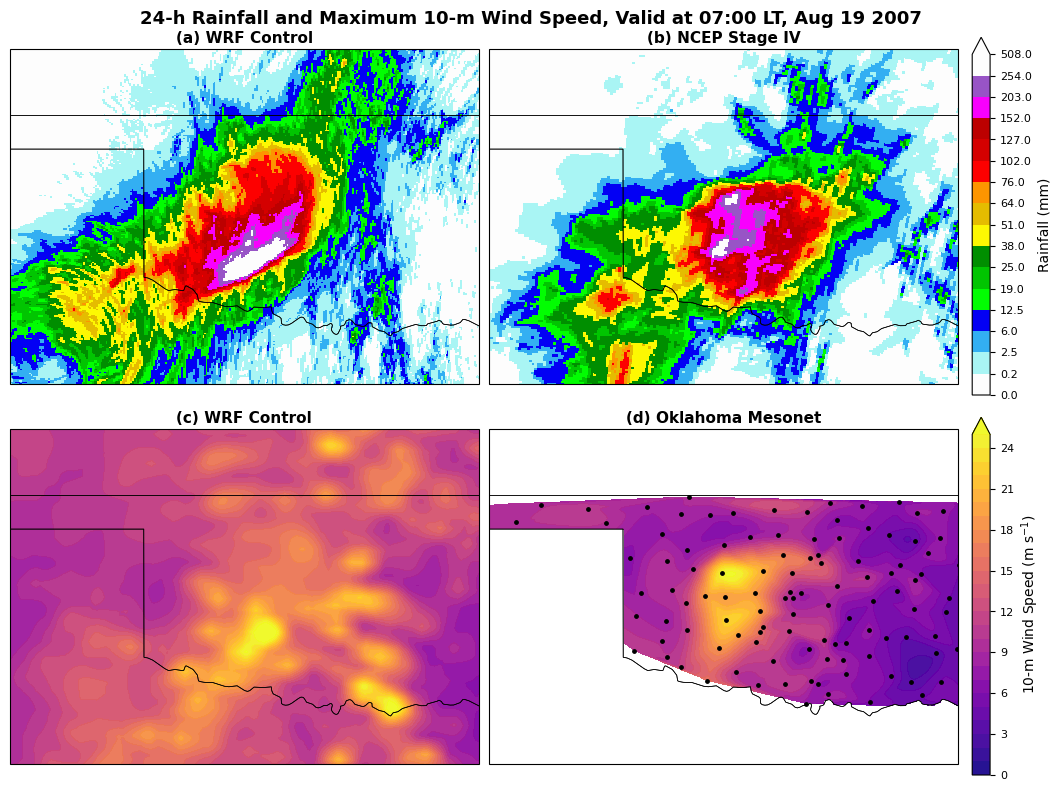

In [ ]:
# Oklahoma polygon
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')
states = shpreader.Reader(shpfilename)
ok_geom = None
for record in states.records():
    if record.attributes['name'] == 'Oklahoma':
        ok_geom = record.geometry
        break

# --- Colors for rainfall ---
nws_precip_colors = [
    "#fdfdfd","#a9f5f4","#33aff2","#0300f4","#02fd02","#01c501","#008e00",
    "#fdf802","#e5bc00","#fd9500","#fd0000","#d40000","#bc0000",
    "#f800fd","#9854c6","#fdfdfd"
]
cmap_rain = mpl.colors.ListedColormap(nws_precip_colors)
# Levels are direct inches to mm conversion of NWS standard levels
levels_rain = [0.0, 0.25, 2.5, 6, 12.5, 19, 25, 38, 51, 64, 76, 102, 127,
               152, 203, 254, 508]
norm_rain = mpl.colors.BoundaryNorm(levels_rain, cmap_rain.N)

# --- Colors for wind ---
cmap_wind = plt.cm.plasma
levels_wind = np.linspace(0, 25, 26)

# --- Plot ---
import shapely
import shapely.vectorized

fig, axes = plt.subplots(
    2, 2,
    figsize=(10.5, 7.6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

extent = [-102, -95, 33, 38]

# --- Top row: Rainfall ---
titles = ['(a) WRF Control', '(b) NCEP Stage IV']
data_list = [(coarse_lon, coarse_lat, coarse_precip),
             (rlon, rlat, tp)]

for ax, (lon_data, lat_data, precip_data), title in zip(axes[0], data_list, titles):
    pcm = ax.pcolormesh(
        lon_data, lat_data, precip_data,
        cmap=cmap_rain, norm=norm_rain,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=11, fontweight='bold', pad=4)
    ax.set_xlabel("Longitude", fontsize=9, labelpad=2)
    ax.set_ylabel("Latitude", fontsize=9, labelpad=2)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8, pad=1)

# Rainfall colorbar on the right
cbar1 = fig.colorbar(
    pcm, ax=axes[0, :],
    orientation='vertical',
    fraction=0.035,
    pad=0.015,
    extend='max',
    ticks=levels_rain
)
cbar1.set_label("Rainfall (mm)", fontsize=10)
cbar1.ax.tick_params(labelsize=8)

# --- Bottom left: WRF max winds ---
ax = axes[1, 0]
cs1 = ax.contourf(
    wrf_lon, wrf_lat, smoothed_wind,
    levels=levels_wind, cmap=cmap_wind,
    transform=ccrs.PlateCarree(),
    alpha=0.95,
    extend='max'
)

ax.set_title("(c) WRF Control", fontsize=11, fontweight='bold', pad=4)
ax.set_xlabel("Longitude", fontsize=9, labelpad=2)
ax.set_ylabel("Latitude", fontsize=9, labelpad=2)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=8, pad=1)

# --- Bottom right: Mesonet max winds ---
ax = axes[1, 1]

if ok_geom is not None:
    mask = shapely.vectorized.contains(ok_geom, xi, yi)
    zi_masked = np.where(mask, zi, np.nan)
else:
    zi_masked = zi

cs2 = ax.contourf(
    xi, yi, zi_masked,
    levels=levels_wind,
    cmap=cmap_wind,
    transform=ccrs.PlateCarree(),
    alpha=0.95,
    extend='max'
)

ax.scatter(
    agg["elon"], agg["nlat"],
    c="black", s=6,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax.set_title("(d) Oklahoma Mesonet", fontsize=11, fontweight='bold', pad=4)
ax.set_xlabel("Longitude", fontsize=9, labelpad=2)
ax.set_ylabel("Latitude", fontsize=9, labelpad=2)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=8, pad=1)

# Wind colorbar on the right
cbar2 = fig.colorbar(
    cs2, ax=axes[1, :],
    orientation='vertical',
    fraction=0.035,
    pad=0.015,
    extend='max'
)
cbar2.set_label("10-m Wind Speed (m s$^{-1}$)", fontsize=10)
cbar2.ax.tick_params(labelsize=8)

# --- Supertitle ---
fig.suptitle(
    "24-h Rainfall and Maximum 10-m Wind Speed, Valid at 07:00 LT, Aug 19 2007",
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.savefig(
    "wrf_stageIV_mesonet_wind_4panel.png",
    dpi=600,
    bbox_inches='tight',
    pad_inches=0.03
)

plt.show()
plt.close(fig)


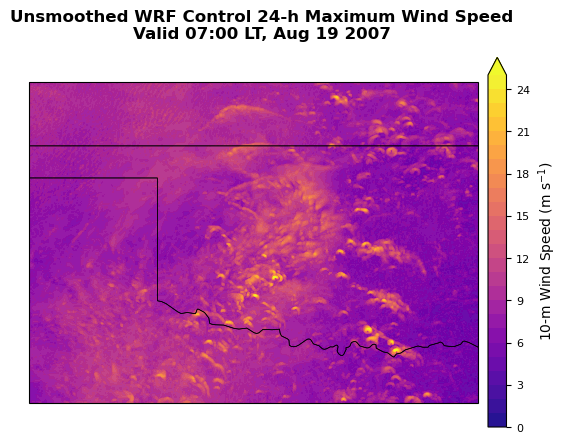

In [12]:
fig, ax = plt.subplots(
    1, 1,
    figsize=(6.2, 4.8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

extent = [-102, -95, 33, 38]

cmap_wind = plt.cm.plasma
levels_wind = np.linspace(0, 25, 26)

cs = ax.contourf(
    wrf_lon, wrf_lat, max_wind,
    levels=levels_wind,
    cmap=cmap_wind,
    transform=ccrs.PlateCarree(),
    alpha=0.95,
    extend='max'
)


ax.set_xlabel("Longitude", fontsize=9, labelpad=2)
ax.set_ylabel("Latitude", fontsize=9, labelpad=2)
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.add_feature(
    cfeature.STATES.with_scale('50m'),
    edgecolor='black',
    linewidth=0.5
)

ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=8, pad=1)

cbar = fig.colorbar(
    cs,
    ax=ax,
    orientation='vertical',
    fraction=0.045,
    pad=0.02,
    extend='max'
)

cbar.set_label("10-m Wind Speed (m s$^{-1}$)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "Unsmoothed WRF Control 24-h Maximum Wind Speed\nValid 07:00 LT, Aug 19 2007",
    fontsize=12,
    fontweight='bold',
    y=0.98
)

plt.savefig(
    "wrf_control_unsmoothed_max_wind_SI.png",
    dpi=600,
    bbox_inches='tight',
    pad_inches=0.03
)

plt.show()
plt.close(fig)

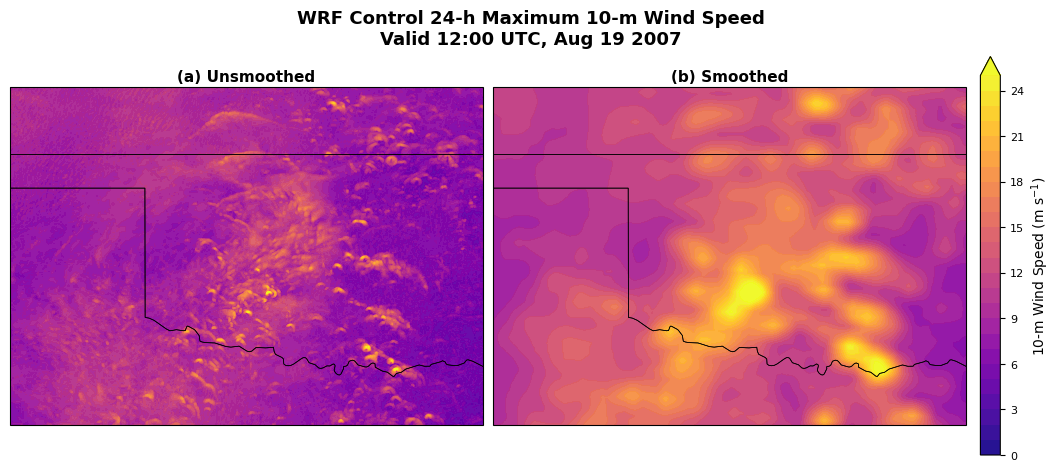

In [13]:


fig, axes = plt.subplots(
    1, 2,
    figsize=(10.5, 4.6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

plot_data = [
    (max_wind, "(a) Unsmoothed"),
    (smoothed_wind, "(b) Smoothed")
]

for ax, (wind_data, title) in zip(axes, plot_data):
    cs = ax.contourf(
        wrf_lon, wrf_lat, wind_data,
        levels=levels_wind,
        cmap=cmap_wind,
        transform=ccrs.PlateCarree(),
        alpha=0.95,
        extend='max'
    )

    ax.set_title(title, fontsize=11, fontweight='bold', pad=4)
    ax.set_xlabel("Longitude", fontsize=9, labelpad=2)
    ax.set_ylabel("Latitude", fontsize=9, labelpad=2)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8, pad=1)

cbar = fig.colorbar(
    cs,
    ax=axes,
    orientation='vertical',
    fraction=0.035,
    pad=0.015,
    extend='max'
)

cbar.set_label("10-m Wind Speed (m s$^{-1}$)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "WRF Control 24-h Maximum 10-m Wind Speed\nValid 12:00 UTC, Aug 19 2007",
    fontsize=13,
    fontweight='bold'
)

plt.savefig(
    "wrf_control_smoothed_vs_unsmoothed_max_wind_SI.png",
    dpi=600,
    bbox_inches='tight',
    pad_inches=0.03
)

plt.show()
plt.close(fig)